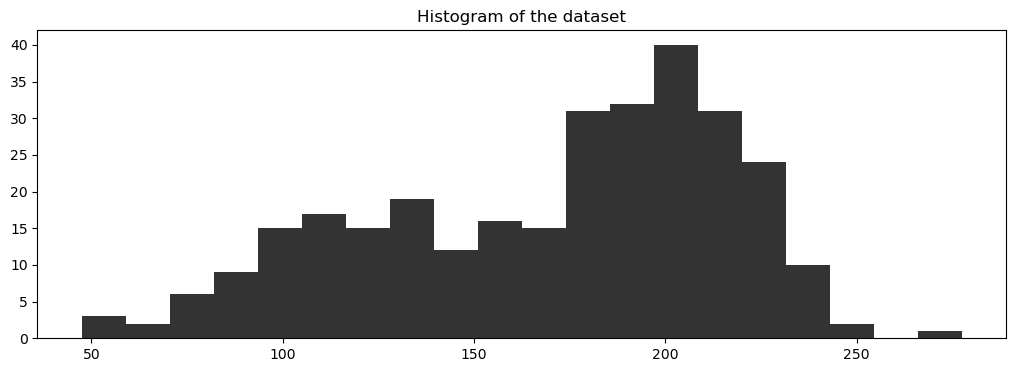

[115.85679142 152.26153716 178.87449059 162.93500815 107.02820697
 105.19141146 118.38288501 125.3769803  102.88054011 206.71326136] ...


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12.5, 4))

# データ読み込み
data = np.loadtxt("mixture_data.csv", delimiter=",")

# ヒストグラム
plt.hist(
    data,
    bins=20,
    color="k",
    histtype="stepfilled",
    alpha=0.8
)

plt.title("Histogram of the dataset")
plt.ylim([0, None])

# 表示
plt.show()

# 先頭10件を確認
print(data[:10], "...")

In [2]:
import pymc as pm
import theano.tensor as T

with pm.Model() as model:
    p1 = pm.Uniform('p', 0, 1)
    p2 = 1 - p1
    p = T.stack([p1, p2])
    assignment = pm.Categorical("assignment", p, 
                                shape=data.shape[0],
                                testval=np.random.randint(0, 2, data.shape[0]))
    
print("prior assignment, with p = %.2f:" % p1.tag.test_value)
print(assignment.tag.test_value[:10])

ModuleNotFoundError: No module named 'pymc'